# Label 信息分析与可视化

这个 notebook 用来读取 Excel 标签文件，快速查看 label 的分布、缺失值、基础统计，并导出清洗后的结果。

使用方式：
1. 修改下面的 `xlsx_path`
2. 从上到下依次运行
3. 查看输出图和导出的统计文件

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import seaborn as sns
HAS_SEABORN = True

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
xlsx_path = Path('/workspace/data/高齢者体回旋20260513.xlsx')
output_dir = xlsx_path.parent / '5_classes_label_analysis_output'
output_dir.mkdir(parents=True, exist_ok=True)

print('xlsx_path =', xlsx_path)
print('output_dir =', output_dir)

if not xlsx_path.exists():
    candidates = sorted(set(Path('/workspace').rglob('*.xlsx')))
    print('File not found. Available xlsx files:')
    for path in candidates:
        print(' -', path)
    raise FileNotFoundError(f'找不到 Excel 文件: {xlsx_path}')

xlsx_path = /workspace/data/高齢者体回旋20260513.xlsx
output_dir = /workspace/data/5_classes_label_analysis_output


In [3]:
excel_file = pd.ExcelFile(xlsx_path)
print('工作表名称:', excel_file.sheet_names)
print('工作表数量:', len(excel_file.sheet_names))

sheet_name = excel_file.sheet_names[0]
df_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)

print('使用工作表:', sheet_name)
print('数据形状:', df_raw.shape)
print('列名:', list(df_raw.columns))


工作表名称: ['諏訪部 (5段階)', '諏訪部', 'Sheet1']
工作表数量: 3
使用工作表: 諏訪部 (5段階)
数据形状: (45, 10)
列名: ['ID', 'ねじり', '姿勢', '脱力', 'Total', '総合（３段階）', '総合（５段階）', '評価に影響した要因', '評価とあまり関係なかった要因', 'Unnamed: 9']


In [4]:
print('字段结构:')
column_summary = pd.DataFrame({
    'column': df_raw.columns,
    'dtype': df_raw.dtypes.astype(str).values,
    'non_null': df_raw.notna().sum().values,
    'null_count': df_raw.isna().sum().values,
    'nunique': [df_raw[col].nunique(dropna=True) for col in df_raw.columns],
})
display(column_summary)

print('基础信息:')
df_raw.info()

# 自动识别可视化的评分/标签列
id_candidates = [col for col in df_raw.columns if str(col).strip().lower() in {'id', 'index', 'no', 'num'}]
numeric_columns = [col for col in df_raw.columns if pd.api.types.is_numeric_dtype(df_raw[col])]
label_columns = ['ねじり', '姿勢', '脱力', '総合（５段階）']

text_columns = [col for col in df_raw.columns if df_raw[col].dtype == 'object']

print('识别到的 ID 列:', id_candidates)
print('识别到的 label 列:', label_columns)
print('识别到的文本列:', text_columns)

字段结构:


,column,dtype,non_null,null_count,nunique
0,ID,int64,45,0,45
1,ねじり,int64,45,0,3
2,姿勢,int64,45,0,3
3,脱力,int64,45,0,3
4,Total,float64,0,45,0
5,総合（３段階）,int64,45,0,3
6,総合（５段階）,int64,45,0,5
7,評価に影響した要因,object,45,0,42
8,評価とあまり関係なかった要因,object,27,18,24
9,Unnamed: 9,object,4,41,3


基础信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              45 non-null     int64  
 1   ねじり             45 non-null     int64  
 2   姿勢              45 non-null     int64  
 3   脱力              45 non-null     int64  
 4   Total           0 non-null      float64
 5   総合（３段階）         45 non-null     int64  
 6   総合（５段階）         45 non-null     int64  
 7   評価に影響した要因       45 non-null     object 
 8   評価とあまり関係なかった要因  27 non-null     object 
 9   Unnamed: 9      4 non-null      object 
dtypes: float64(1), int64(6), object(3)
memory usage: 3.6+ KB
识别到的 ID 列: ['ID']
识别到的 label 列: ['ねじり', '姿勢', '脱力', '総合（５段階）']
识别到的文本列: ['評価に影響した要因', '評価とあまり関係なかった要因', 'Unnamed: 9']


In [5]:
# 标签范围定义
label_ranges = {
    'ねじり': [1, 2, 3],
    '姿勢': [1, 2, 3],
    '脱力': [1, 2, 3],
    '総合（５段階）': [1, 2, 3, 4, 5],
}


label_stats = []
label_counts_map = {}

df = df_raw.copy()

for col in label_columns:
    valid_labels = label_ranges.get(col, sorted(df[col].dropna().unique()))
    df[label_columns] = df[label_columns].astype(np.int64)

    # 只统计非缺失值
    s = df[col].dropna()

    counts = (
        s.value_counts()
        .reindex(valid_labels, fill_value=0)
        .rename_axis('label')
        .reset_index(name='count')
    )

    counts['ratio'] = counts['count'] / counts['count'].sum() if counts['count'].sum() > 0 else 0
    counts['ratio_percent'] = (counts['ratio'] * 100).round(2)
    counts['column'] = col

    label_counts_map[col] = counts

    top_row = counts.sort_values('count', ascending=False).iloc[0]

    label_stats.append({
        'column': col,
        'unique_labels': int(s.nunique()),
        'non_null': int(df[col].notna().sum()),
        'missing': int(df[col].isna().sum()),
        'top_label': top_row['label'],
        'top_count': int(top_row['count']),
        'top_ratio_percent': round(top_row['ratio'] * 100, 2),
    })

label_summary = pd.DataFrame(label_stats)

print('标签列概览:')
display(label_summary)

for col, counts in label_counts_map.items():
    print(f'[{col}] 分布:')
    display(counts)

unique_label_total = sum(item['unique_labels'] for item in label_stats)
print('标签列数量:', len(label_columns))
print('标签唯一值总数:', unique_label_total)

标签列概览:


,column,unique_labels,non_null,missing,top_label,top_count,top_ratio_percent
0,ねじり,3,45,0,2,28,62.22
1,姿勢,3,45,0,2,23,51.11
2,脱力,3,45,0,3,20,44.44
3,総合（５段階）,5,45,0,1,10,22.22


[ねじり] 分布:


,label,count,ratio,ratio_percent,column
0,1,5,0.111111,11.11,ねじり
1,2,28,0.622222,62.22,ねじり
2,3,12,0.266667,26.67,ねじり


[姿勢] 分布:


...

[脱力] 分布:


,label,count,ratio,ratio_percent,column
0,1,9,0.200000,20.00,脱力
1,2,16,0.355556,35.56,脱力
2,3,20,0.444444,44.44,脱力


[総合（５段階）] 分布:


,label,count,ratio,ratio_percent,column
0,1,10,0.222222,22.22,総合（５段階）
1,2,9,0.200000,20.00,総合（５段階）
2,3,9,0.200000,20.00,総合（５段階）
3,4,10,0.222222,22.22,総合（５段階）
4,5,7,0.155556,15.56,総合（５段階）


标签列数量: 4
标签唯一值总数: 14


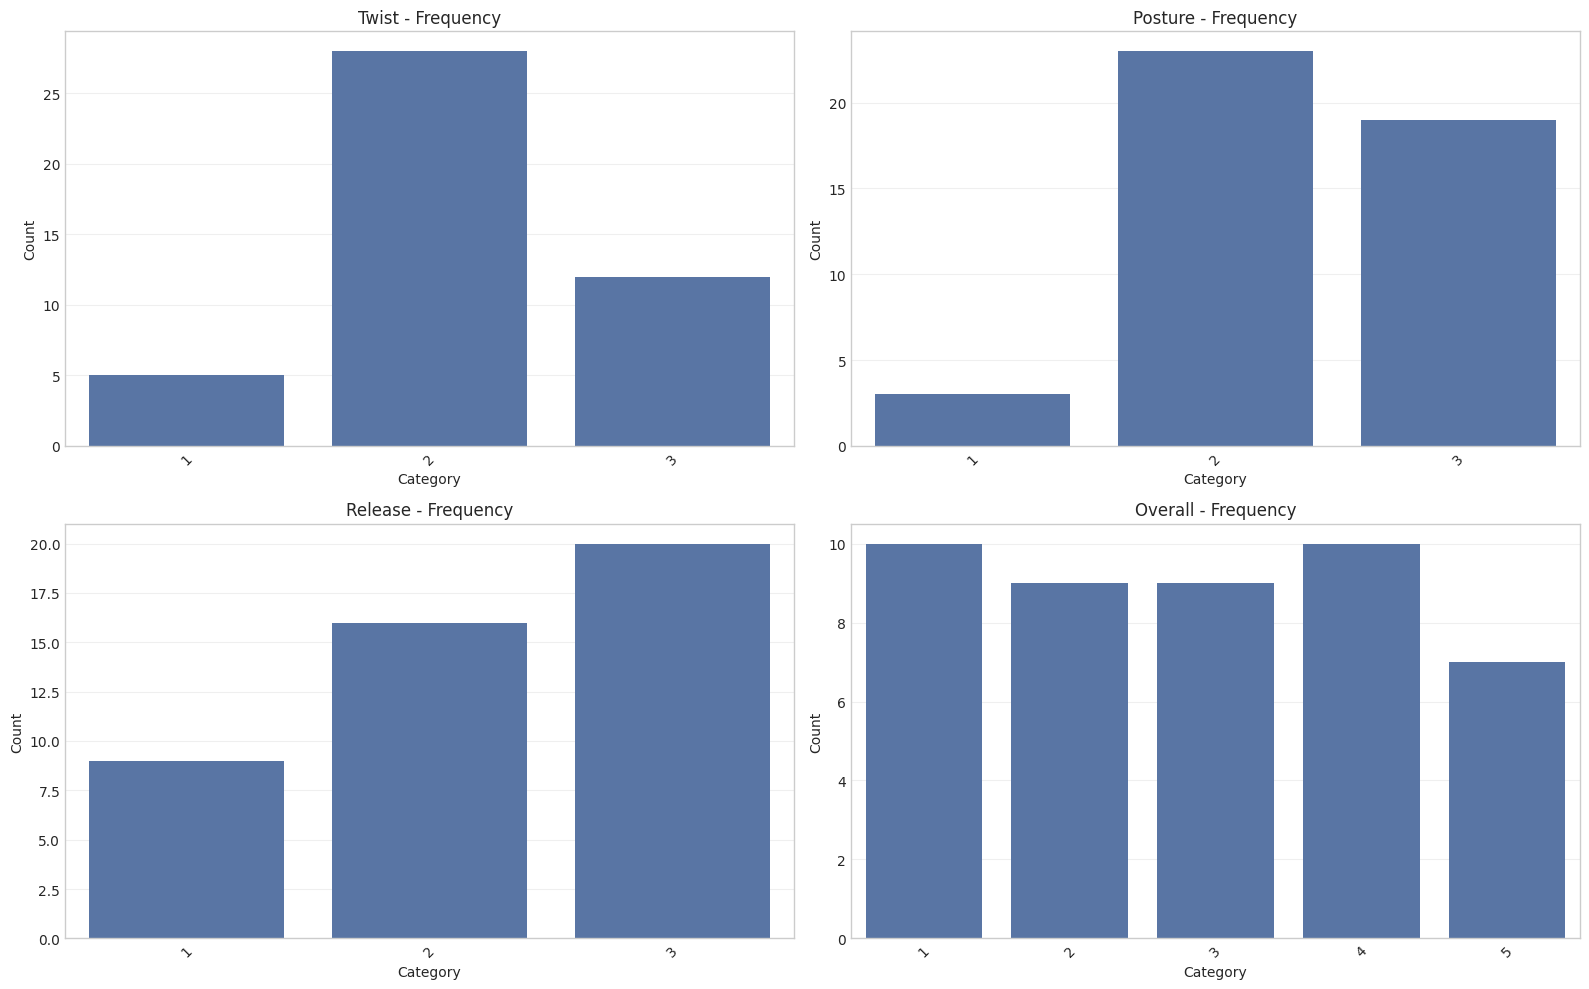

In [6]:
n_cols = 2
n_rows = int(np.ceil(len(label_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.array(axes).reshape(-1)

column_title_map = {
    'ねじり': 'Twist',
    '姿勢': 'Posture',
    '脱力': 'Release',
    '総合（５段階）': 'Overall',
}

for idx, col in enumerate(label_columns):
    ax = axes[idx]
    plot_df = label_counts_map[col].sort_values('count', ascending=False)
    title_name = column_title_map.get(col, str(col))

    if HAS_SEABORN:
        sns.barplot(data=plot_df, x='label', y='count', ax=ax, color='#4C72B0')
    else:
        ax.bar(plot_df['label'].astype(str), plot_df['count'], color='#4C72B0')

    ax.set_title(f'{title_name} - Frequency')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='y', alpha=0.3)

for ax in axes[len(label_columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
stats_path = output_dir / 'label_summary.csv'
counts_path = output_dir / 'label_value_counts_long.csv'
clean_path = output_dir / 'label_data_cleaned.csv'

label_summary.to_csv(stats_path, index=False, encoding='utf-8-sig')
pd.concat(label_counts_map.values(), ignore_index=True).to_csv(counts_path, index=False, encoding='utf-8-sig')
df.to_csv(clean_path, index=False, encoding='utf-8-sig')


print('已导出:')
print(' -', stats_path)
print(' -', counts_path)
print(' -', clean_path)

已导出:
 - /workspace/data/5_classes_label_analysis_output/label_summary.csv
 - /workspace/data/5_classes_label_analysis_output/label_value_counts_long.csv
 - /workspace/data/5_classes_label_analysis_output/label_data_cleaned.csv


## 运行结果说明

- 图表会直接显示在 notebook 中。
- 导出的文件保存在 `label_analysis_output/` 下。
- 如果 Excel 文件不在默认路径，请修改第 3 个单元里的 `xlsx_path`。